### This code is great if you want to quickly plot the fits of the circle of the nyquist plots

2025-08-19 11:42:09.573 python[31856:9298696] +[CATransaction synchronize] called within transaction


{'time(mins)': 0.0, 'Cp1': None, 'Ph1': None, 'Rct_semicircle': None, 'Rs': None, 'fit_success': False, 'xc': None, 'yc': None, 'r': None, 'Sheet': '10 nM Cas complex_Association'}
{'time(mins)': 1.5, 'Cp1': None, 'Ph1': None, 'Rct_semicircle': None, 'Rs': None, 'fit_success': False, 'xc': None, 'yc': None, 'r': None, 'Sheet': '10 nM Cas complex_Association'}
{'time(mins)': 3.0, 'Cp1': None, 'Ph1': None, 'Rct_semicircle': None, 'Rs': None, 'fit_success': False, 'xc': None, 'yc': None, 'r': None, 'Sheet': '10 nM Cas complex_Association'}
{'time(mins)': 4.5, 'Cp1': None, 'Ph1': None, 'Rct_semicircle': None, 'Rs': None, 'fit_success': False, 'xc': None, 'yc': None, 'r': None, 'Sheet': '10 nM Cas complex_Association'}
{'time(mins)': 6.0, 'Cp1': None, 'Ph1': None, 'Rct_semicircle': None, 'Rs': None, 'fit_success': False, 'xc': None, 'yc': None, 'r': None, 'Sheet': '10 nM Cas complex_Association'}
{'time(mins)': 7.5, 'Cp1': None, 'Ph1': None, 'Rct_semicircle': None, 'Rs': None, 'fit_success'

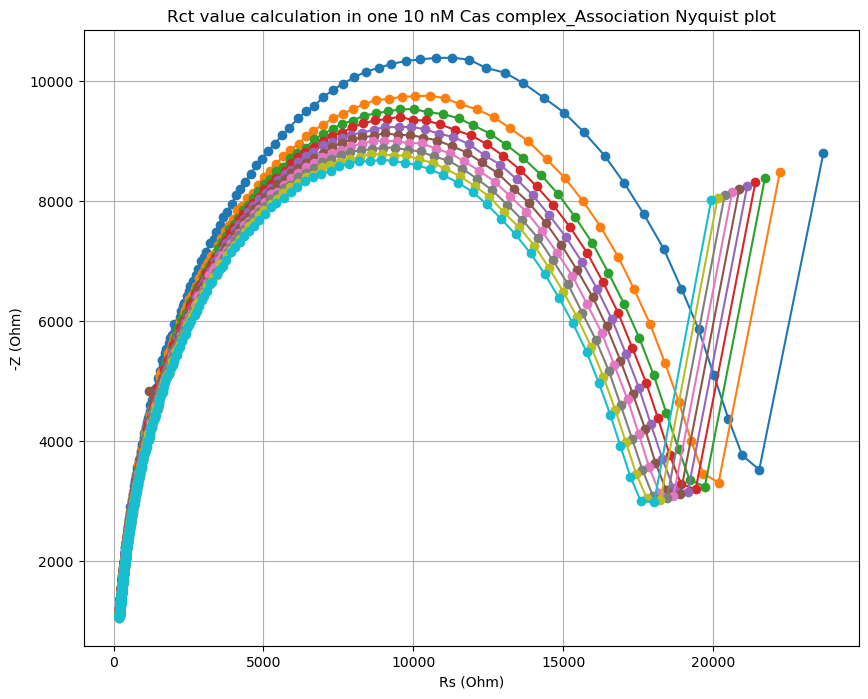

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from tkinter import filedialog, Tk, Listbox, MULTIPLE, Button, END
#from circle_fit import taubinSVD
from scipy.optimize import least_squares

# ------------------------------
# File loading utilities
# ------------------------------
def manualloadfile():
    folderpath = "/Users/deeptabharadwaj/Downloads/Chip46_EIS_Data Analysis"
    root = Tk()
    root.filename = filedialog.askopenfilename(
        initialdir=folderpath,
        title="Select file",
        filetypes=(("Excel files", "*.xlsx"), ("all files", "*.*"))
    )
    root.destroy()
    return root.filename, pd.ExcelFile(root.filename, engine='openpyxl')


def select_sheets(xls):
    root = Tk()
    root.title('Select Sheets')

    listbox = Listbox(root, selectmode=MULTIPLE)
    listbox.pack(padx=10, pady=10)

    for sheet in xls.sheet_names:
        listbox.insert(END, sheet)

    def on_select():
        global selected_sheets
        selected_sheets = [listbox.get(i) for i in listbox.curselection()]
        root.destroy()

    button = Button(root, text='Select', command=on_select)
    button.pack(pady=10)

    root.mainloop()
    return selected_sheets


# ------------------------------
# Circle fitting + analysis
# ------------------------------

def fit_circle_geometric(points):
    """Geometric circle fit using nonlinear least squares"""
    def residuals(params, x, y):
        a, b, r = params
        return np.sqrt((x - a)**2 + (y - b)**2) - r

    # initial guess: center ~ mean, radius ~ mean distance
    x_m, y_m = np.mean(points, axis=0)
    r_m = np.mean(np.sqrt((points[:,0]-x_m)**2 + (points[:,1]-y_m)**2))
    initial_guess = [x_m, y_m, r_m]

    result = least_squares(residuals, initial_guess, args=(points[:,0], points[:,1]))
    a_fit, b_fit, r_fit = result.x
    return a_fit, b_fit, r_fit


def deepta_analysis_functions(df, cycle_idx, time_per_cycle, cp1, ph1):
    results = {
        "time(mins)": time_per_cycle * cycle_idx,
        "Cp1": cp1,
        "Ph1": ph1,
        "Rct_semicircle": None,
        "Rs": None,
        "fit_success": False,
        "xc": None,
        "yc": None,
        "r": None
    }

    x_raw = pd.to_numeric(df["Rs"], errors="coerce").to_numpy()
    y_raw = pd.to_numeric(df["X"], errors="coerce").to_numpy()
    mask = np.isfinite(x_raw) & np.isfinite(y_raw)
    x_raw = x_raw[mask]
    y_raw = np.abs(y_raw[mask])

    if len(x_raw) < 3:
        return results

    idx_min_y = np.argmin(y_raw)
    x_circle = x_raw[idx_min_y:]
    y_circle = y_raw[idx_min_y:]

    if len(x_circle) < 3:
        return results

    try:
        circle_coords = np.column_stack((x_circle, y_circle))
        #xc, yc, r, sigma = taubinSVD(circle_coords)
        xc, yc, r = fit_circle_geometric(circle_coords)

        results.update({
            "Rct_semicircle": 2 * r,
            "Rs": xc - r,
            "fit_success": True,
            "xc": xc,
            "yc": yc,
            "r": r
        })
    except Exception:
        return results

    return results


# ------------------------------
# Main processing (no saving)
# ------------------------------
def darken_color(color, factor=0.7):
    """Return a darker shade of the given color."""
    rgb = np.array(to_rgb(color))
    rgb_darker = rgb * factor
    return rgb_darker


def main():
    file_path, xls = manualloadfile()
    selected_sheets = select_sheets(xls)

    totalTime = 30  # min experiment duration
    all_results = []

    for sheet_name in selected_sheets:
        df = pd.read_excel(xls, sheet_name)

        maxFrequency = 200000
        maxFreqIndices = df.loc[df['Frequency(Hz)'] == maxFrequency].index.to_numpy()
        maxFreqIndices = np.append(-1, maxFreqIndices)

        plt.figure(figsize=(10, 8))
        plt.title(f"Rct value calculation in one {sheet_name} Nyquist plot")
        plt.xlabel("Rs (Ohm)")
        plt.ylabel("-Z (Ohm)")
        plt.grid(True)

        for i in range(len(maxFreqIndices) - 1):
            section_df = df.iloc[maxFreqIndices[i] + 1:maxFreqIndices[i + 1] + 1]
            res = deepta_analysis_functions(section_df, i, 1.5, None, None)
            res["Sheet"] = sheet_name
            all_results.append(res)
            print(res)

            # Plot Nyquist segment
            x_vals = section_df["Rs"].to_numpy()
            y_vals = -section_df["X"].to_numpy()
            nyquist_line, = plt.plot(x_vals, y_vals, 'o-', label=f"Cycle {i}")  # capture the line

            # Plot circle if fit was successful
            if res["fit_success"]:
                theta = np.linspace(0, 2*np.pi, 400)
                circle_x = res["r"] * np.cos(theta) + res["xc"]
                circle_y = res["r"] * np.sin(theta) + res["yc"]
                darker_color = darken_color(nyquist_line.get_color(), factor=0.7)
                plt.plot(circle_x, circle_y, '--', linewidth=2, color=darker_color)

        
        plt.show()


if __name__ == "__main__":
    main()


2025-08-19 11:52:26.862 python[32074:9305833] +[CATransaction synchronize] called within transaction


selected_sheets : ['10 nM Cas complex_Association']
[188.993 185.096]
{'time(mins)': 0.0, 'Cp1': None, 'Ph1': None, 'Rct_semicircle': None, 'Rs': None, 'fit_success': False, 'xc': None, 'yc': None, 'r': None, 'Sheet': '10 nM Cas complex_Association'}
[182.435]
{'time(mins)': 1.5, 'Cp1': None, 'Ph1': None, 'Rct_semicircle': None, 'Rs': None, 'fit_success': False, 'xc': None, 'yc': None, 'r': None, 'Sheet': '10 nM Cas complex_Association'}
[182.292 182.961]
{'time(mins)': 3.0, 'Cp1': None, 'Ph1': None, 'Rct_semicircle': None, 'Rs': None, 'fit_success': False, 'xc': None, 'yc': None, 'r': None, 'Sheet': '10 nM Cas complex_Association'}
[181.678]
{'time(mins)': 4.5, 'Cp1': None, 'Ph1': None, 'Rct_semicircle': None, 'Rs': None, 'fit_success': False, 'xc': None, 'yc': None, 'r': None, 'Sheet': '10 nM Cas complex_Association'}
[184.874 179.555]
{'time(mins)': 6.0, 'Cp1': None, 'Ph1': None, 'Rct_semicircle': None, 'Rs': None, 'fit_success': False, 'xc': None, 'yc': None, 'r': None, 'Sheet': '1

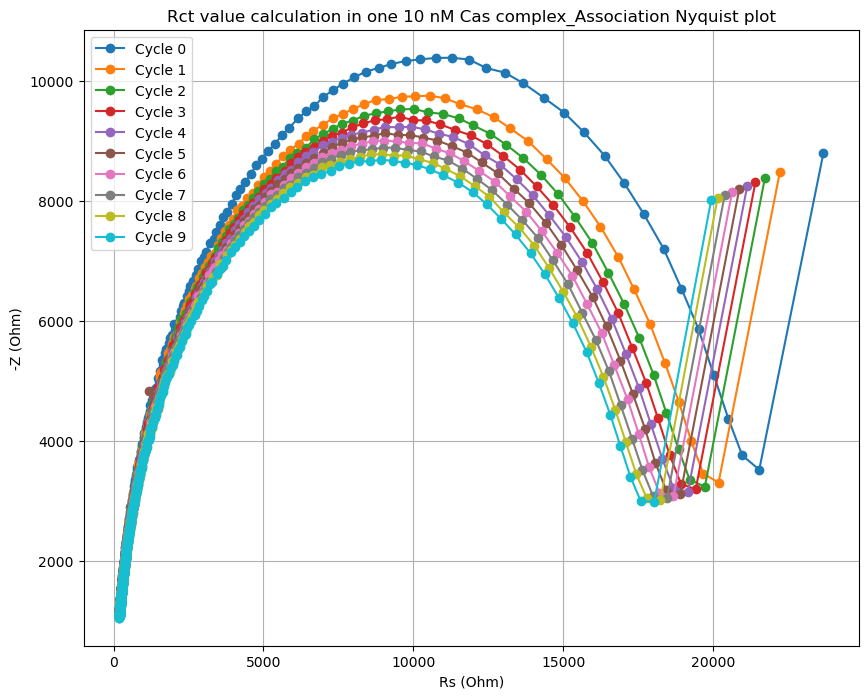

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from tkinter import filedialog, Tk, Listbox, MULTIPLE, Button, END
from scipy.optimize import least_squares

# ------------------------------
# File loading utilities
# ------------------------------
def manualloadfile():
    folderpath = "/Users/deeptabharadwaj/Downloads/Chip46_EIS_Data Analysis"
    root = Tk()
    root.filename = filedialog.askopenfilename(
        initialdir=folderpath,
        title="Select file",
        filetypes=(("Excel files", "*.xlsx"), ("all files", "*.*"))
    )
    root.destroy()
    return root.filename, pd.ExcelFile(root.filename, engine='openpyxl')


def select_sheets(xls):
    root = Tk()
    root.title('Select Sheets')

    listbox = Listbox(root, selectmode=MULTIPLE)
    listbox.pack(padx=10, pady=10)

    for sheet in xls.sheet_names:
        listbox.insert(END, sheet)

    def on_select():
        global selected_sheets
        selected_sheets = [listbox.get(i) for i in listbox.curselection()]
        root.destroy()

    button = Button(root, text='Select', command=on_select)
    button.pack(pady=10)

    root.mainloop()
    return selected_sheets


# ------------------------------
# Circle fitting + analysis
# ------------------------------

def fit_circle_geometric(points):
    """Geometric circle fit using nonlinear least squares"""
    def residuals(params, x, y):
        a, b, r = params
        return np.sqrt((x - a)**2 + (y - b)**2) - r

    # initial guess: center ~ mean, radius ~ mean distance
    x_m, y_m = np.mean(points, axis=0)
    r_m = np.mean(np.sqrt((points[:,0]-x_m)**2 + (points[:,1]-y_m)**2))
    initial_guess = [x_m, y_m, r_m]

    result = least_squares(residuals, initial_guess, args=(points[:,0], points[:,1]))
    a_fit, b_fit, r_fit = result.x
    return a_fit, b_fit, r_fit


def deepta_analysis_functions(df, cycle_idx, time_per_cycle, cp1, ph1):
    results = {
        "time(mins)": time_per_cycle * cycle_idx,
        "Cp1": cp1,
        "Ph1": ph1,
        "Rct_semicircle": None,
        "Rs": None,
        "fit_success": False,
        "xc": None,
        "yc": None,
        "r": None
    }

    x_raw = pd.to_numeric(df["Rs"], errors="coerce").to_numpy()
    y_raw = pd.to_numeric(df["X"], errors="coerce").to_numpy()
    mask = np.isfinite(x_raw) & np.isfinite(y_raw)
    x_raw = x_raw[mask]
    y_raw = -y_raw[mask]   # use negative to match Nyquist convention

    if len(x_raw) < 3:
        return results

    idx_min_y = np.argmin(y_raw)
    x_circle = x_raw[idx_min_y:]
    y_circle = y_raw[idx_min_y:]
    print(x_circle)
    if len(x_circle) < 3:
        return results

    try:
        circle_coords = np.column_stack((x_circle, y_circle))
        xc, yc, r = fit_circle_geometric(circle_coords)
        print("hi")

        results.update({
            "Rct_semicircle": 2 * r,
            "Rs": xc - r,
            "fit_success": True,
            "xc": xc,
            "yc": yc,
            "r": r
        })
    except Exception:
        return results

    return results


# ------------------------------
# Main processing (no saving)
# ------------------------------
def darken_color(color, factor=0.7):
    """Return a darker shade of the given color."""
    rgb = np.array(to_rgb(color))
    rgb_darker = rgb * factor
    return rgb_darker


def main():
    #file_path, xls = manualloadfile()
    file_path = "/Users/deeptabharadwaj/Downloads/Chip21_EIS_Data Analysis.xlsx"
    
    #selected_sheets = select_sheets(xls)
    selected_sheets = ['10 nM Cas complex_Association']
    
    totalTime = 30  # min experiment duration
    all_results = []

    for sheet_name in selected_sheets:
        df = pd.read_excel(xls, sheet_name)

        maxFrequency = 200000
        maxFreqIndices = df.loc[df['Frequency(Hz)'] == maxFrequency].index.to_numpy()
        maxFreqIndices = np.append(-1, maxFreqIndices)

        plt.figure(figsize=(10, 8))
        plt.title(f"Rct value calculation in one {sheet_name} Nyquist plot")
        plt.xlabel("Rs (Ohm)")
        plt.ylabel("-Z (Ohm)")
        plt.grid(True)

        for i in range(len(maxFreqIndices) - 1):
            section_df = df.iloc[maxFreqIndices[i] + 1:maxFreqIndices[i + 1] + 1]
            res = deepta_analysis_functions(section_df, i, 1.5, None, None)
            res["Sheet"] = sheet_name
            all_results.append(res)
            print(res)

            # Plot Nyquist segment
            x_vals = section_df["Rs"].to_numpy()
            y_vals = -section_df["X"].to_numpy()  # negative for Nyquist
            nyquist_line, = plt.plot(x_vals, y_vals, 'o-', label=f"Cycle {i}")

            # Plot circle if fit was successful
            if res["fit_success"]:
                theta = np.linspace(0, 2*np.pi, 400)
                circle_x = res["r"] * np.cos(theta) + res["xc"]
                circle_y = res["r"] * np.sin(theta) + res["yc"]
                darker_color = darken_color(nyquist_line.get_color(), factor=0.7)
                plt.plot(circle_x, circle_y, '--', linewidth=2, color=darker_color, label=f"Fit {i}")

        plt.legend()
        plt.show()


if __name__ == "__main__":
    main()
